<a href="https://colab.research.google.com/github/Abhisek963/machineLearning_Lab/blob/main/26March02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

In [ ]:
df = pd.read_csv("new.csv")
print("Shape:", df.shape)
df.drop(columns=["ID"], inplace=True, errors="ignore")

Shape: (2240, 29)


In [ ]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"], errors="coerce")
df["TenureDays"]=(pd.Timestamp.today() - df["Dt_Customer"]).dt.days
df.drop(columns=["Dt_Customer"], inplace=True)
df["Age"] = 2024 - df["Year_Birth"]
df["TotalSpend"] = df[["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]].sum(axis=1)
df["TotalBuys"] = df["NumWebPurchases"] + df["NumCatalogPurchases"] + df["NumStorePurchases"]
df["CmpAccepted"] = df[["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]].sum(axis=1)

In [ ]:
print("Missing before:", df.isna().sum().sum())
df["Income"]=df["Income"].fillna(df["Income"].median())
df.dropna(inplace=True)
print("Shape after cleaning:", df.shape)

Missing before: 0
Shape after cleaning: (916, 32)


In [ ]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols=df.select_dtypes(include=["object"]).columns.tolist()

In [ ]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), cat_cols),])
X = preprocessor.fit_transform(df)
print("X shape:", X.shape)

X shape: (916, 40)


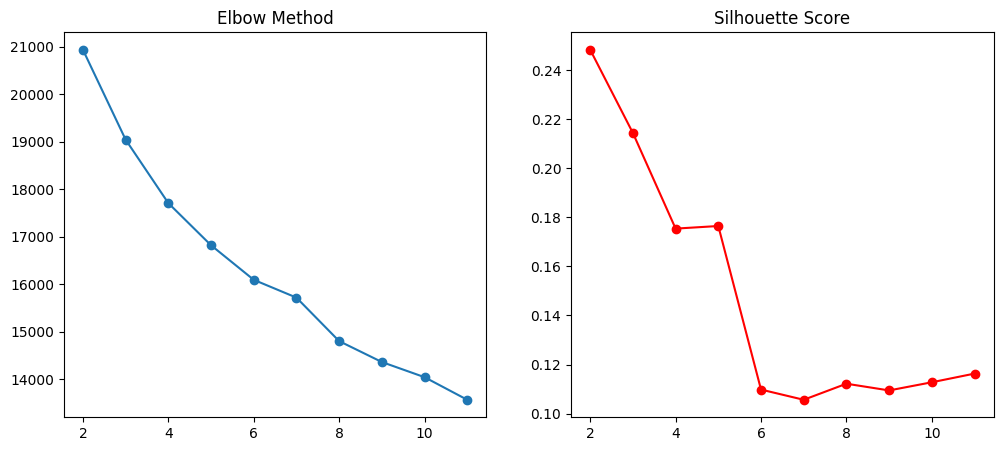

In [ ]:
inertias = []
sil_scores = []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K_range, inertias, marker="o")
plt.title("Elbow Method")
plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, marker="o", color="red")
plt.title("Silhouette Score")
plt.show()

In [ ]:
best_k=3
print("Best k:", best_k)
km_final=KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X)
df["Cluster"] = cluster_labels
print(df["Cluster"].value_counts())

Best k: 3
Cluster
1    466
2    355
0     95
Name: count, dtype: int64


In [ ]:
profile_cols = ["Age","Income","TotalSpend","TotalBuys","TenureDays","CmpAccepted"]
print(df.groupby("Cluster")[profile_cols].mean().round(2))

           Age    Income  TotalSpend  TotalBuys  TenureDays  CmpAccepted
Cluster                                                                 
0        52.87  81428.99     1630.82      19.86     4658.35         2.43
1        53.09  37310.47      127.87       6.62     4630.02         0.15
2        58.13  67037.39      991.48      18.61     4694.03         0.31


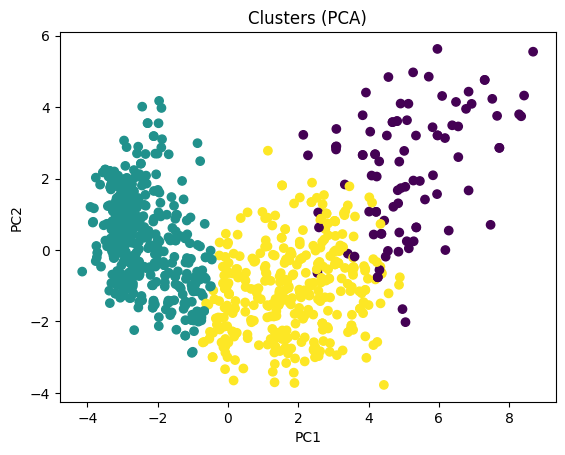

In [ ]:
pca=PCA(n_components=2)
X_2d=pca.fit_transform(X)

plt.scatter(X_2d[:,0], X_2d[:,1], c=cluster_labels)
plt.title("Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
X_clf=preprocessor.transform(df.drop(columns=["Cluster"]))
X_train, X_test, y_train, y_test = train_test_split(X_clf, cluster_labels, test_size=0.2, random_state=42)

Naive Bayes Report:

              precision    recall  f1-score   support

           0       0.36      1.00      0.53        17
           1       1.00      0.98      0.99        96
           2       0.95      0.58      0.72        71

    accuracy                           0.83       184
   macro avg       0.77      0.85      0.75       184
weighted avg       0.92      0.83      0.84       184



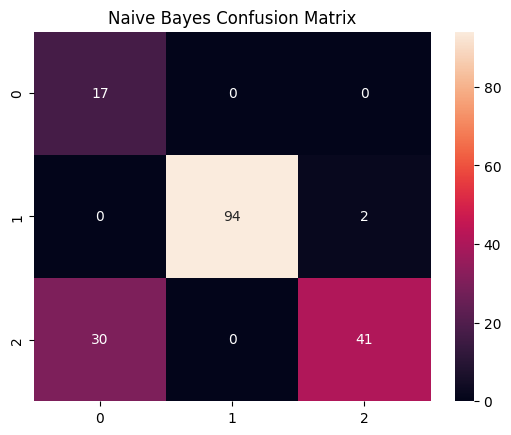

In [ ]:
nb=GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb=nb.predict(X_test)
print("Naive Bayes Report:\n")
print(classification_report(y_test, y_pred_nb))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Logistic Regression Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      0.98      0.99        96
           2       0.97      1.00      0.99        71

    accuracy                           0.99       184
   macro avg       0.99      0.99      0.99       184
weighted avg       0.99      0.99      0.99       184



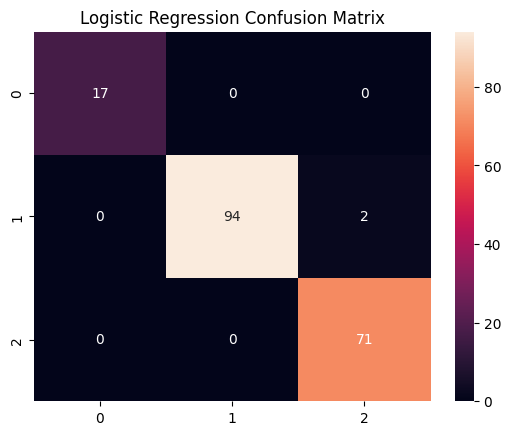

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()